In [31]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [32]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/tarot_dataset')

In [33]:
import os

os.listdir('/content/tarot_dataset')

['cards', 'tarot-images.json']

In [34]:
os.listdir('/content/tarot_dataset/cards')[:10]

['c11.jpg',
 'm01.jpg',
 'm20.jpg',
 'm04.jpg',
 'm18.jpg',
 'w04.jpg',
 'w09.jpg',
 'p12.jpg',
 'm19.jpg',
 'p01.jpg']

In [35]:
import json

with open('/content/tarot_dataset/tarot-images.json', 'r') as f:
    data = json.load(f)

print(type(data))
print(len(data))

<class 'dict'>
2


**Import Libraries**

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import cv2

sns.set_style("whitegrid")

**Load JSON**

In [37]:
import json
import pandas as pd

with open('/content/tarot_dataset/tarot-images.json', 'r') as f:
    data = json.load(f)

print(type(data))

# If the JSON has a top-level "cards" key
if isinstance(data, dict) and "cards" in data:
    df = pd.json_normalize(data["cards"])
else:
    df = pd.json_normalize(data)

df.head()

<class 'dict'>


,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"[Freeing yourself from limitation, Expressing ...","[Being gullible and naive, Taking unnecessary ...",NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...","[Taking appropriate action, Receiving guidance...","[Inflating your own ego, Abusing talents, Mani...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...","[Listening to your feelings and intuitions, Ex...","[Being aloof, Obsessing on secrets and conspir...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,"[Nurturing yourself and others, Bearing fruit,...","[Overindulging, Being greedy, Smothering someo...",NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,"[Exercising authority, Defining limits, Direct...","[Micromanaging, Crushing the creativity of oth...",NaN,NaN


Basic Dataset Information

In [38]:
print("Dataset Shape:", df.shape)
print("\n")

df.info()

print("\n")

df.describe(include="all")

Dataset Shape: (78, 17)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   Archetype           22 non-null     object
 8   Hebrew Alphabet     22 non-null     object
 9   Numerology          62 non-null     object
 10  Elemental           38 non-null     object
 11  Mythical/Spiritual  22 non-null     object
 12  Questions to Ask    78 non-null     object
 13  meanings.light      78 non-null     object
 14  meanings.shadow     78 non-null     object
 15  Astrology           40 non-null     object
 16  Af

,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
count,78,78,78,78,78,78,78,22,22,62,38,22,78,78,78,40,56
unique,78,22,2,5,78,78,78,22,22,33,38,22,78,78,78,40,56
top,The Fool,1,Minor Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]",The Divine Madman,Aleph/Ox/1,"4 (The Status Quo: stability, equality, persis...",Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"[Freeing yourself from limitation, Expressing ...","[Being gullible and naive, Taking unnecessary ...","Cancer, Scorpio, Pisces","""I listen to the counsel of my heart."""
freq,1,5,56,22,1,1,1,1,1,4,1,1,1,1,1,1,1


Missing Values

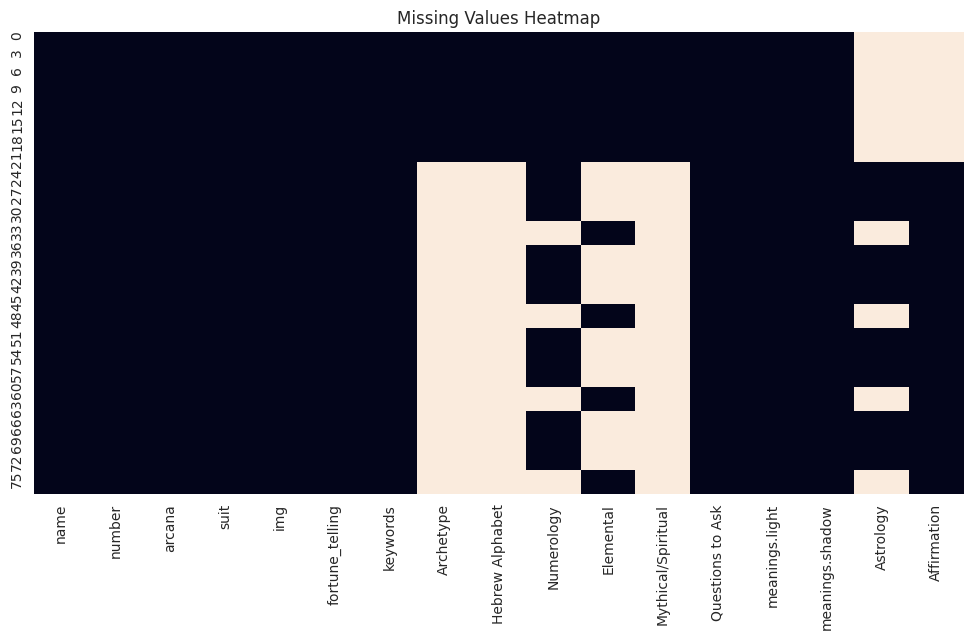

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [40]:
df.isnull().sum()

,0
name,0
number,0
arcana,0
suit,0
img,0
fortune_telling,0
keywords,0
Archetype,56
Hebrew Alphabet,56
Numerology,16


Duplicate Records

In [41]:
print(df.columns.tolist())

['name', 'number', 'arcana', 'suit', 'img', 'fortune_telling', 'keywords', 'Archetype', 'Hebrew Alphabet', 'Numerology', 'Elemental', 'Mythical/Spiritual', 'Questions to Ask', 'meanings.light', 'meanings.shadow', 'Astrology', 'Affirmation']


In [42]:
df_temp = df.copy()

for col in df_temp.columns:
    df_temp[col] = df_temp[col].astype(str)

print("Duplicate Records:", df_temp.duplicated().sum())

Duplicate Records: 0


Arcana Distribution

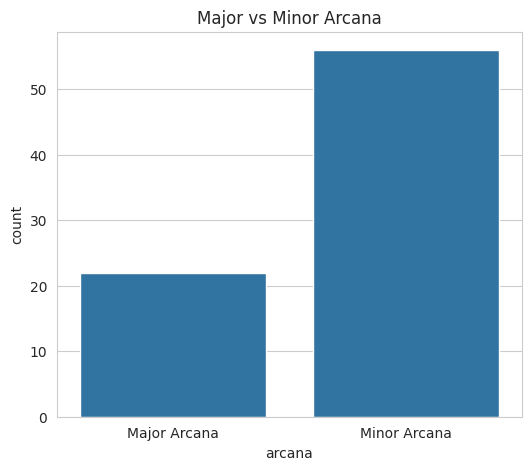

arcana
Minor Arcana    56
Major Arcana    22
Name: count, dtype: int64


In [43]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='arcana')

plt.title("Major vs Minor Arcana")
plt.show()

print(df["arcana"].value_counts())

Suit Distribution

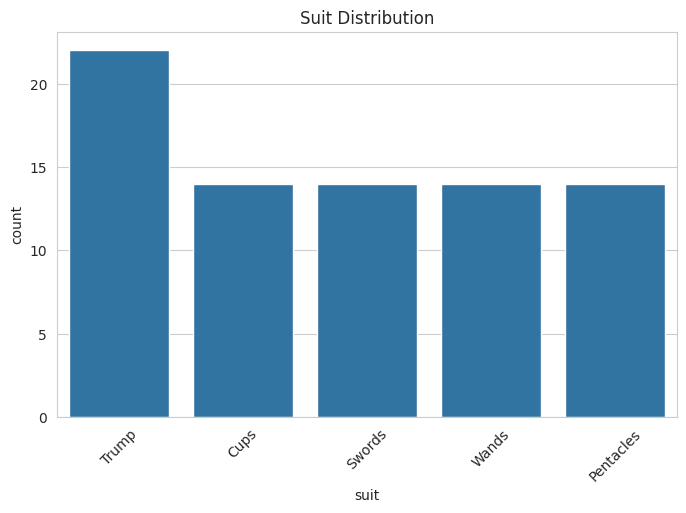

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='suit',
    order=df['suit'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Suit Distribution")

plt.show()

Card Number Distribution

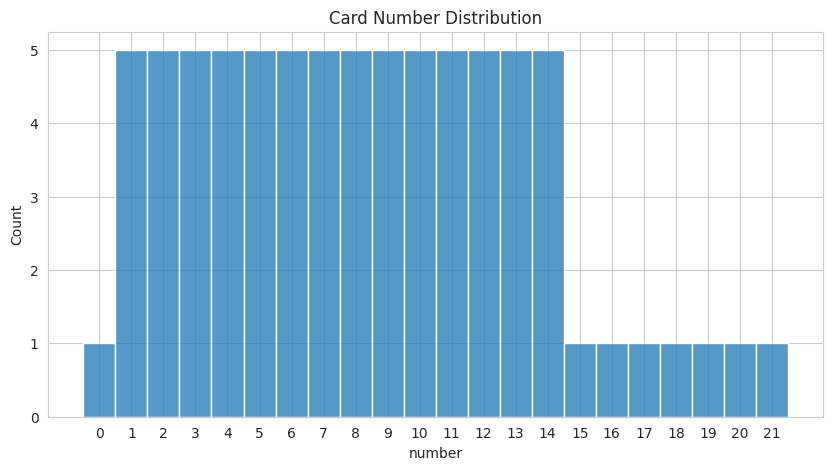

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(df["number"], bins=15)

plt.title("Card Number Distribution")

plt.show()

Fortune-Telling Statements Count

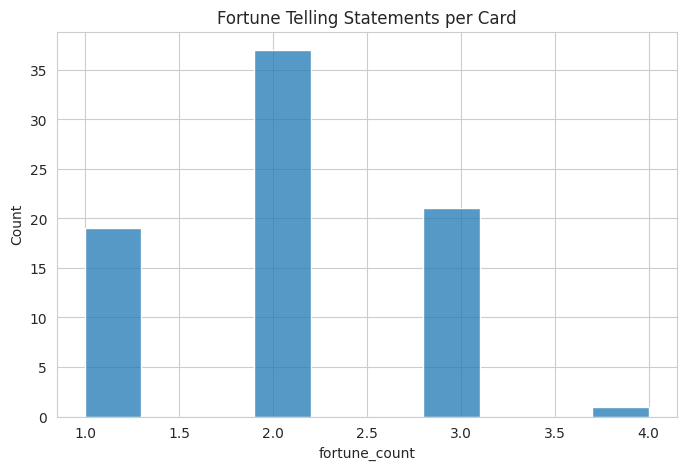

,fortune_count
count,78.000000
mean,2.051282
std,0.754165
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,4.000000


In [46]:
df["fortune_count"] = df["fortune_telling"].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["fortune_count"], bins=10)

plt.title("Fortune Telling Statements per Card")

plt.show()

df["fortune_count"].describe()

Keyword Count

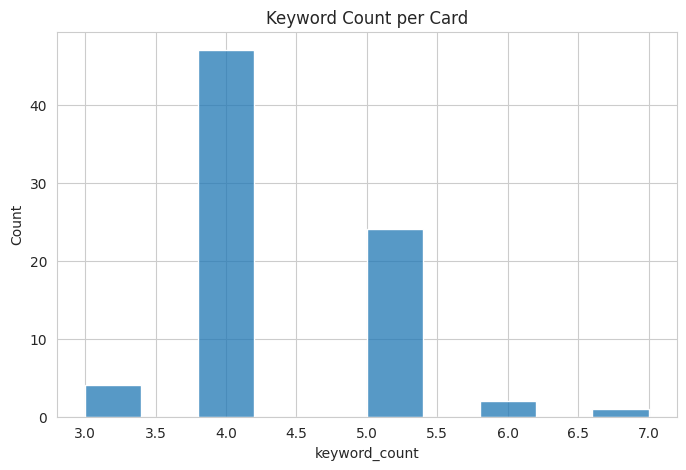

,keyword_count
count,78.000000
mean,4.346154
std,0.680468
min,3.000000
25%,4.000000
50%,4.000000
75%,5.000000
max,7.000000


In [47]:
df["keyword_count"] = df["keywords"].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["keyword_count"], bins=10)

plt.title("Keyword Count per Card")

plt.show()

df["keyword_count"].describe()

Meaning Length

In [48]:
df["light_meaning_length"] = df["meanings.light"].apply(
    lambda x: len(" ".join(x).split())
)

df["shadow_meaning_length"] = df["meanings.shadow"].apply(
    lambda x: len(" ".join(x).split())
)

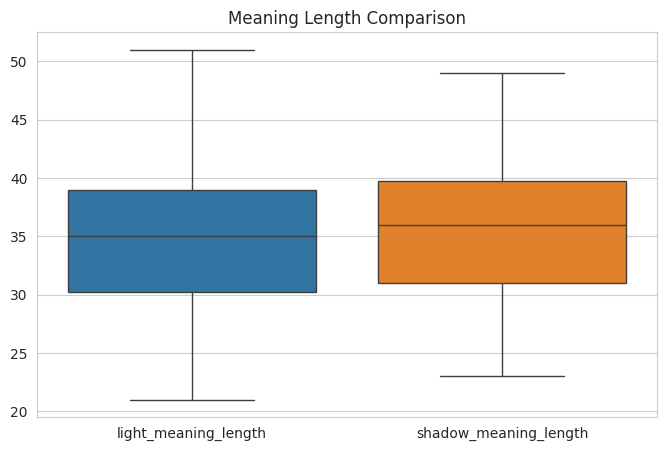

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[
        [
            "light_meaning_length",
            "shadow_meaning_length"
        ]
    ]
)

plt.title("Meaning Length Comparison")

plt.show()

Question Count

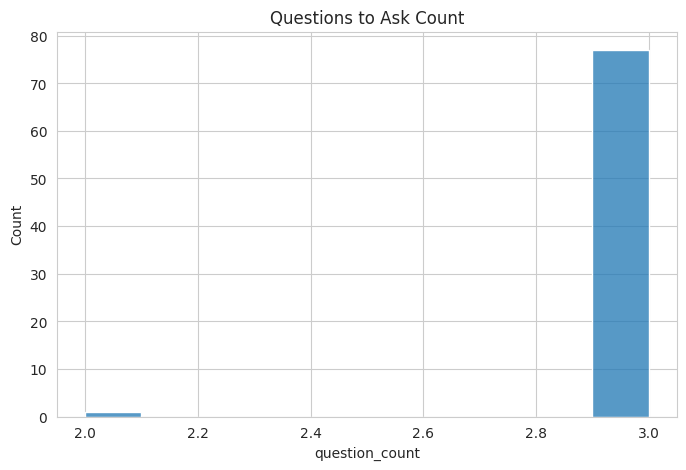

In [50]:
df["question_count"] = df["Questions to Ask"].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["question_count"], bins=10)

plt.title("Questions to Ask Count")

plt.show()

Display Sample Images

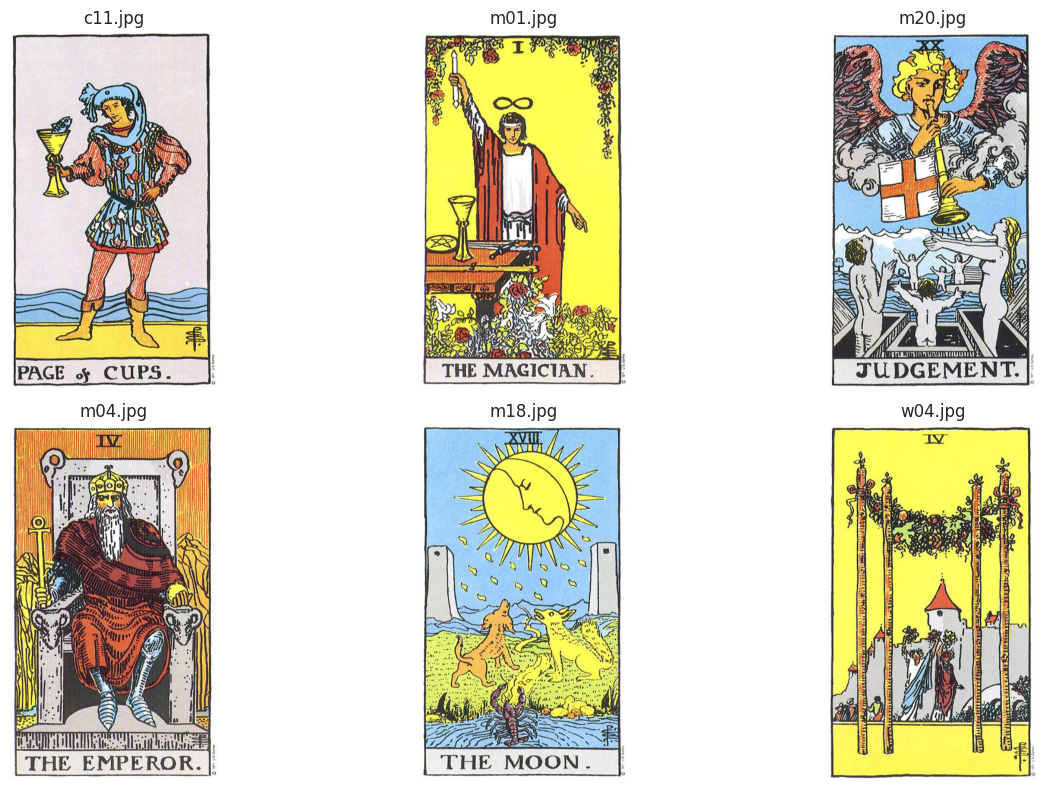

In [51]:
import os
import cv2

folder="/content/tarot_dataset/cards"

files=os.listdir(folder)

plt.figure(figsize=(14,8))

for i,file in enumerate(files[:6]):

    img=cv2.imread(os.path.join(folder,file))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

plt.tight_layout()

plt.show()

Image Resolution

In [52]:
heights=[]
widths=[]

for file in os.listdir(folder):

    img=cv2.imread(os.path.join(folder,file))

    h,w,_=img.shape

    heights.append(h)
    widths.append(w)

print("Average Height :",sum(heights)/len(heights))
print("Average Width :",sum(widths)/len(widths))

Average Height : 600.0
Average Width : 350.0


RGB Histogram

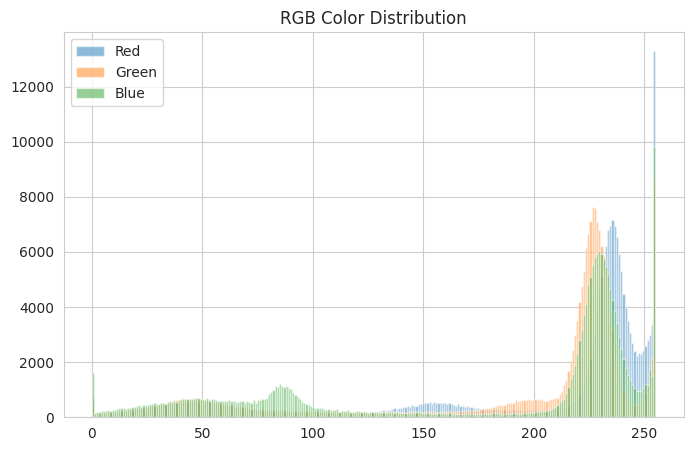

In [53]:
sample=cv2.imread(os.path.join(folder,files[0]))
sample=cv2.cvtColor(sample,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,5))

plt.hist(sample[:,:,0].ravel(),bins=256,alpha=0.5,label="Red")
plt.hist(sample[:,:,1].ravel(),bins=256,alpha=0.5,label="Green")
plt.hist(sample[:,:,2].ravel(),bins=256,alpha=0.5,label="Blue")

plt.legend()

plt.title("RGB Color Distribution")

plt.show()

Image Size Consistency

In [54]:
sizes=[]

for file in os.listdir(folder):

    img=cv2.imread(os.path.join(folder,file))

    sizes.append(img.shape)

pd.Series(sizes).value_counts()

,count
"(600, 350, 3)",78


Correlation Heatmap

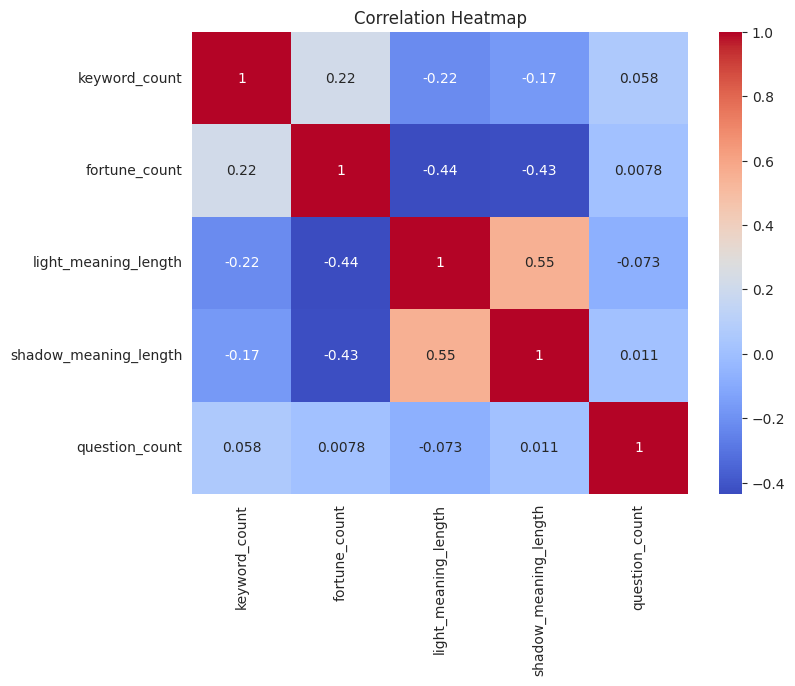

In [55]:
features=df[
    [
        "keyword_count",
        "fortune_count",
        "light_meaning_length",
        "shadow_meaning_length",
        "question_count"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(features.corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

Dataset Summary

In [56]:
print("Total Cards :",len(df))

print("Major Arcana :",(df["arcana"]=="Major").sum())

print("Minor Arcana :",(df["arcana"]=="Minor").sum())

print("Unique Suits :",df["suit"].nunique())

print("Images :",len(os.listdir(folder)))

Total Cards : 78
Major Arcana : 0
Minor Arcana : 0
Unique Suits : 5
Images : 78
